# 1. Bibliotecas

In [1]:
# Biblioteca fundamental para as demais. fornece principalmente
# arrays e matrizes mais eficientes
import numpy as np
# Biblioteca para estruturação, limpeza e manipulação de dados
# em tabelas
import pandas as pd
# Módulo do MatPlotLib para criação de gráficos 
import matplotlib.pyplot as plt

# train_test_split -> separa um conjunto de dados entre "treino"
# e "testes"
from sklearn.model_selection import train_test_split
# normalização padrão para dados numéricos
from sklearn.preprocessing import StandardScaler
# Classe para executar os principais métodos de processamento de dados
# e treinamento de máquina, passo a passo; tudo em um único objeto
# e sem expor os dados
from sklearn.pipeline import Pipeline
# Classe da Máquina de Vetores de Suporte, com foco em Classificação
from sklearn.svm import SVC
# accuracy_score -> testa a acurácia dos resultados do modelo com base
# nos resultados de teste
# confusion_matrix -> tranforma os resultados obtidos em uma "matriz de
# certeza" com base nos resultados de teste
# ConfusionMatrixDisplay -> Classe para Visualizar de forma gráfica, o 
# retorno de confusion_matrix()
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 2. Dataset

## O Dataset Iris
O Dataset Iris é um Dataset clássico em ambientes acadêmicos para ensinar sobre, entre outros conteúdos, treinamento de máquina supervisionado.


O Dataset conta com 150 resgistros de 3 diferentes tipos de Íris, sendo elas _setosa_, _versicolor_ e _virginica_. As colunas estão organizadas em: "comprimento da sépala", "largura da sépala", "comprimento da pétala" e "Largura da pétala", além da coluna "species" que identifica espécie de flor de cada registro.

## Importando o csv
O csv já salvo será importado e já convertido em um DataFrame do Pandas, utilizando o método ``pd.read_csv("/caminho.csv")``.

alguns métodos em ``df_iris`` são feitas para confirmar que o Dataset foi corretamente importado:


In [2]:
df_iris = pd.read_csv("/kaggle/input/datasets/menegidio/iris-species/Iris.csv")

print("Tamanho:",df_iris.shape) # imprime as dimensões da tabela (linha,coluna)

# imprime a contagem de valores de cada valor na coluna "Species"
# nesse caso, devem ser 3 valores com 50 unidades contadas cada
print("\n",df_iris["Species"].value_counts())

df_iris.head() # mostra as 5 primeiras linhas

Tamanho: (150, 6)

 Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Análise do Dataset

É importante que, antes de treinar o modelo, é preciso entender os dados que estão sendo trabalhados e se eles possuem, lacunas, falhas ou outliers que possam interferir no treinamento e resultados final do modelo.

Vamos adicionar uma coluna ``IdSpecie`` para identificar as especies de maneira númerica:

In [3]:
# pd.factorize(array) -> atribui um código em valor inteiro
# para valores únicos em um array
df_iris["IdSpecie"] = pd.factorize(df_iris["Species"])[0]

# descreve o DataFrame
df_iris.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,IdSpecie
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667,1.000000
std,43.445368,0.828066,0.433594,1.764420,0.763161,0.819232
min,1.000000,4.300000,2.000000,1.000000,0.100000,0.000000
25%,38.250000,5.100000,2.800000,1.600000,0.300000,0.000000
50%,75.500000,5.800000,3.000000,4.350000,1.300000,1.000000
75%,112.750000,6.400000,3.300000,5.100000,1.800000,2.000000
max,150.000000,7.900000,4.400000,6.900000,2.500000,2.000000


Com um simples Gráfico de dispersão, é possível ver a relação entre esses dados, até então, apararentemente soltos: 

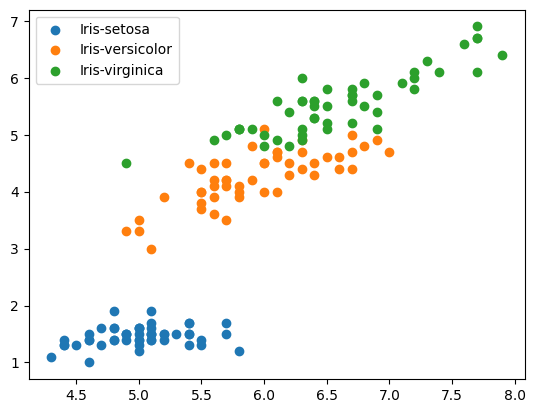

In [4]:
plt.figure()

for s, dado in df_iris.groupby("Species"):
    plt.scatter(dado["SepalLengthCm"],dado["PetalLengthCm"],label=s)

plt.legend()
plt.show()

# 3. Support Vector Machine (Classificação)

## Separação dos Dados e dos Rótulos
Com a Criação da coluna ``IdSpecie``, podemos separar melhor os dados de uma forma que o modelo possa utilizar.

Agora vamos criar as principais variáveis que dividem os dados dos rótulos: "X" e "y":

In [5]:
# Dados
# .iloc[linhas, colunas] -> pega um recorte do DataFrame
X = df_iris.iloc[:,1:5].copy()
# Rótulos
y = df_iris["IdSpecie"].copy()

In [6]:
X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: IdSpecie, dtype: int64

## Dados de Treino e de Teste

Os dados serão novamente divididos, agora entre dados de treino e de teste. Essa divisão deve ser feita para que o modelo não conheça inicialmente todos os dados.

In [8]:
# test_size -> quantidade reservada para testes. 0.2 = 20%
# random_state -> embaralhamento aleatório antes da divisão entre 
# treino e teste
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

## Pipeline e SVC

Com os dados corretamente separados, será criado o modelo que treinará com eles.

Para isso, vamos utilizar um ``Pipeline``, objeto que executa passo a passo, de forma segura, o processamento dos dados e o aprendizado de máquina, incluindo o SVC:

In [9]:
iris_pipeline = Pipeline(
    [
        ("scaler",StandardScaler()), # normalização de valores numéricos
        ("svm", SVC(kernel="linear")) # modelo SVM de Classificação
    ]
)

print(iris_pipeline)

Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC(kernel='linear'))])


## Treino

O treino é feito em uma simples linha de código, passando os dados e rótulos de treino:

In [10]:
iris_pipeline.fit(X,y)

Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC(kernel='linear'))])

## Previsão

A Previsão será feita passando apenas os dados de teste``X_test``, e o resultado será armazenado em ``y_pred``:

In [11]:
y_pred = iris_pipeline.predict(X_test)

print(y_pred) # valores previstos pelo SVC, com base no seu treinamento

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


# 4. Resultados e Análise

## Teste de Acurácia

O teste de Acurácia verifica se os resultados entregues pelo modelo, batem com os reais, armazenados em ``y_test``. Esse resultado varia entre 0.0 e 1.0:

In [12]:
print(f"Acurácia do modelo treinado: {accuracy_score(y_test, y_pred):.2f} de 1.00")

Acurácia do modelo treinado: 1.00 de 1.00


## Matriz de Confusão

A matriz de confusão também é um ótimo jeito de visualizar a precisão do seu modelo. Quanto mais precisa for a matriz principal, e apenas 0 nas outras células, melhor foi o resultado do modelo:

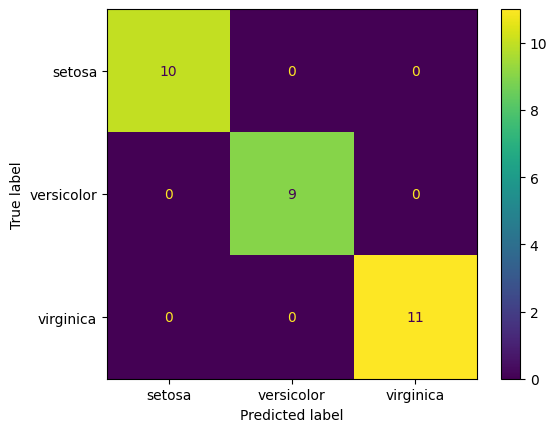

In [13]:
cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["setosa","versicolor","virginica"])
disp.plot()
plt.show()